In [22]:
%config InlineBackend.close_figures = False

# 14 — Gesture triplet-loss embedder

First trained model in Prototype 2, following the design agreed in project
conversation: reuse P1's architecture (256->128->32 MLP, batch-all triplet
loss, margin 0.20, L2-normalised output) rather than redesigning from
scratch, applied to **gesture** rather than typing -- gesture and tap are
now roughly tied on the raw-distance baseline (gap-to-shuffled-control
~+0.29 both, after the device-fingerprint features were removed), and
gesture has more surviving features (101 vs tap's 83).

**What this compares against**: the raw-distance baseline already measured
in `evaluate_trust_windows.py` -- cohort-normalised AUC ~0.73 at a single
15s window, ~0.78 at 158s (fixed identity set, `strict` feature profile).
That baseline used NO learned transformation, so any improvement here is
attributable to the embedding step specifically, which is the same
comparison logic P1's Section 7.2 baseline was built for.

**Two things carried over deliberately, because they mattered a lot in the
baseline work**:

1. **Cohort-normalised scoring at evaluation time.** This was the single
   biggest lever in the raw-distance baseline (+0.14 AUC at k=1) and there
   is no reason it stops applying once embeddings are learned -- a trained
   embedder's raw distances will still carry the same per-probe-window
   offset. Evaluation below reuses that exact normalisation.
2. **The negative control runs on the TRAINED model, not just the raw
   baseline.** A trained embedder is more expressive than a distance
   baseline, so it is MORE capable of learning to separate sessions rather
   than identity if a confound slipped through -- not less. Skipping this
   check because "the baseline already passed it" would defeat the point.


In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.decomposition import PCA

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
gesture_path = find(str(MOD_DIR / 'gesture_windows.parquet'), 'gesture_windows.parquet',
                     '/mnt/user-data/uploads/gesture_windows.parquet')
splits_path = find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv',
                    '/mnt/user-data/uploads/identity_splits.csv')

df = pd.read_parquet(gesture_path)
splits = pd.read_csv(splits_path)
df = df.merge(splits[['sessionId', 'role']], on='sessionId', how='inner')
print(f"gesture windows: {df.shape}, sessions matched to splits: {df['sessionId'].nunique()}")
print(df.groupby('role').size())


gesture windows: (3054, 114), sessions matched to splits: 86
role
enrol     545
probe     350
train    2159
dtype: int64


## 1. Feature preparation

Same rule as the evaluation harness: a feature needs to be populated in at
least 50% of gesture-eligible windows to be used. Impute (median) and scale
(standardise) fit on `train`-role windows only -- P1 Section 8.4's leakage
control -- never on enrol/probe.

In [24]:
ID = {'sessionId','participantId','deviceFamily','window_index','window_start_s','window_end_s',
      'taskIndex','taskType','activeArea','task_pass','task_start_s','task_end_s','role'}

feats = [c for c in df.columns if c not in ID and pd.api.types.is_numeric_dtype(df[c])]
coverage = df[feats].notna().mean()
feats = coverage[coverage >= 0.5].index.tolist()
print(f"{len(feats)} features used")

train_df = df[df['role'] == 'train']
imputer = SimpleImputer(strategy='median').fit(train_df[feats])
scaler = StandardScaler().fit(imputer.transform(train_df[feats]))

def embed_input(sub):
    return scaler.transform(imputer.transform(sub[feats])).astype(np.float32)

X_all = embed_input(df)
y_all = df['participantId'].values
role_all = df['role'].values
print(f"X_all: {X_all.shape}")


61 features used
X_all: (3054, 61)


## 2. Batch composition check

Triplet loss needs multiple identities and multiple windows per identity in
the same batch to construct valid triplets. Checked directly rather than
assumed, since this cohort is much smaller than a typical biometrics
dataset (17 identities total, 15 with any train-role data).

participantId
pCURDWC     22
pG2C8BC     26
pEAB9GS     31
pCTJ44P     35
pUNKH7L     45
pEZVKTS     56
pZMC82M     56
pA6XL23     80
pWJGKPK     80
pAFQRTM     91
pNDG8LJ    159
pG5G4MS    200
p3YDMHG    300
pH3S4X4    470
p95MPVX    508


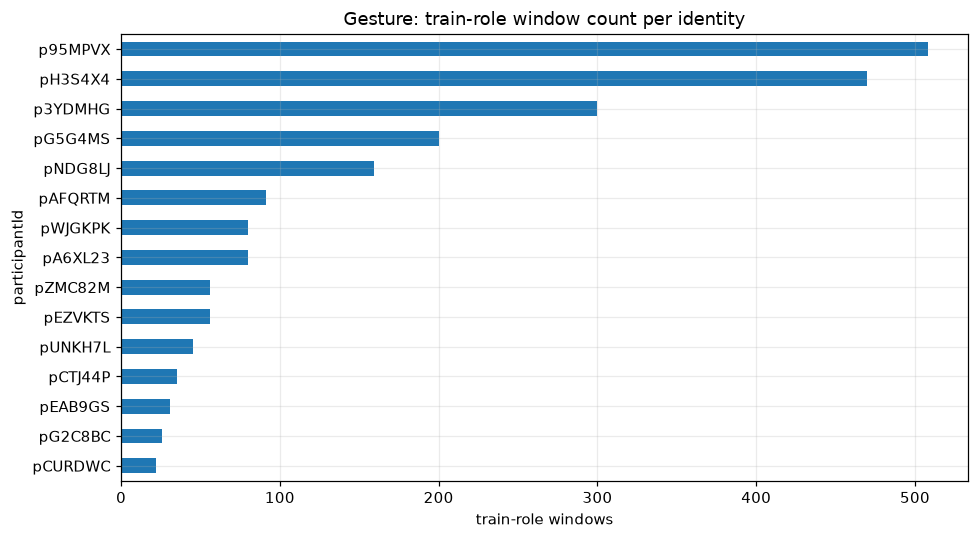

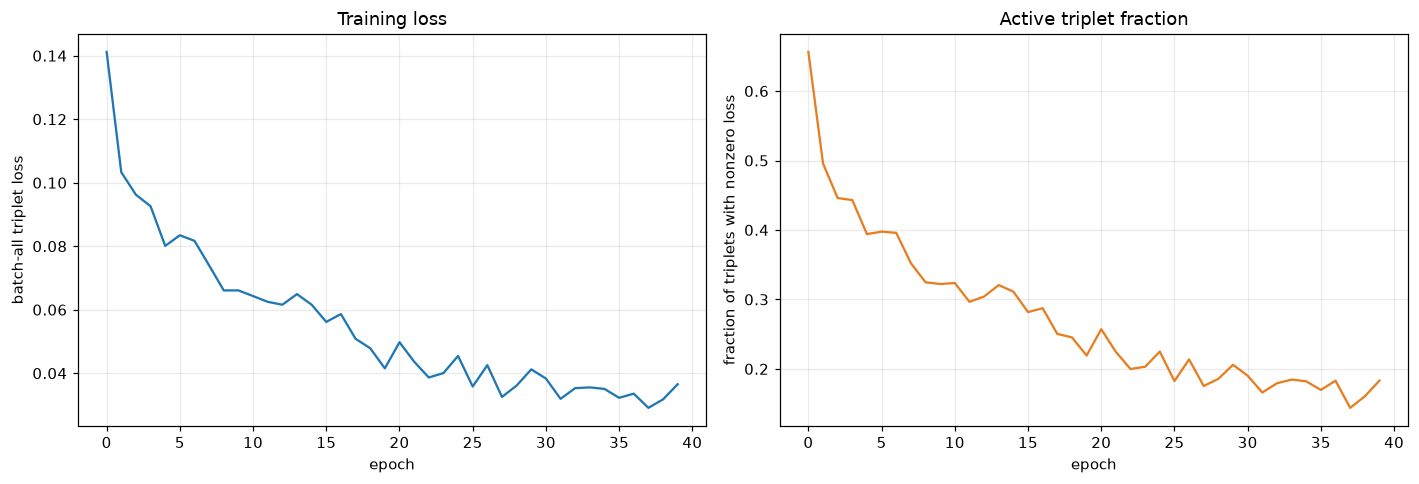

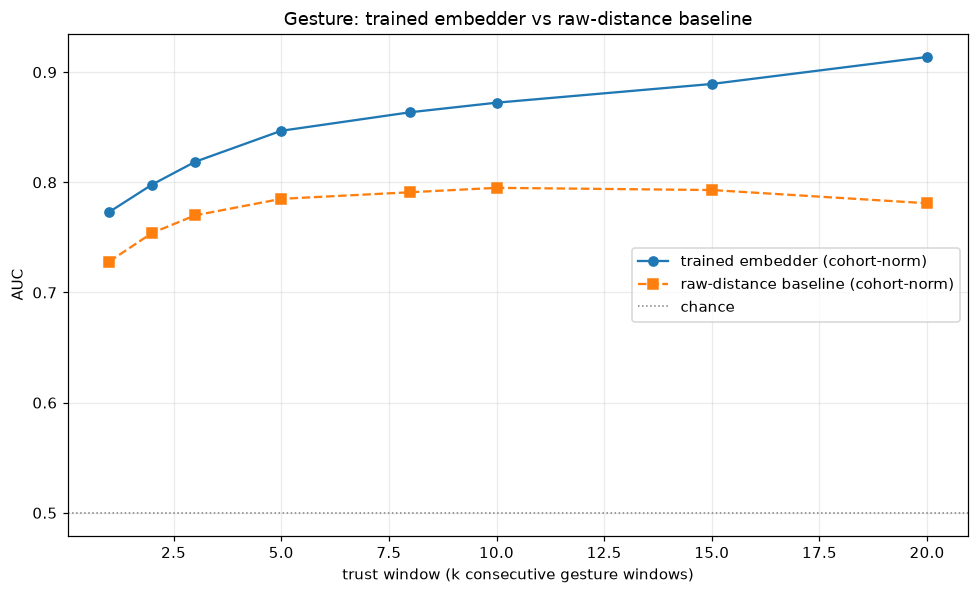

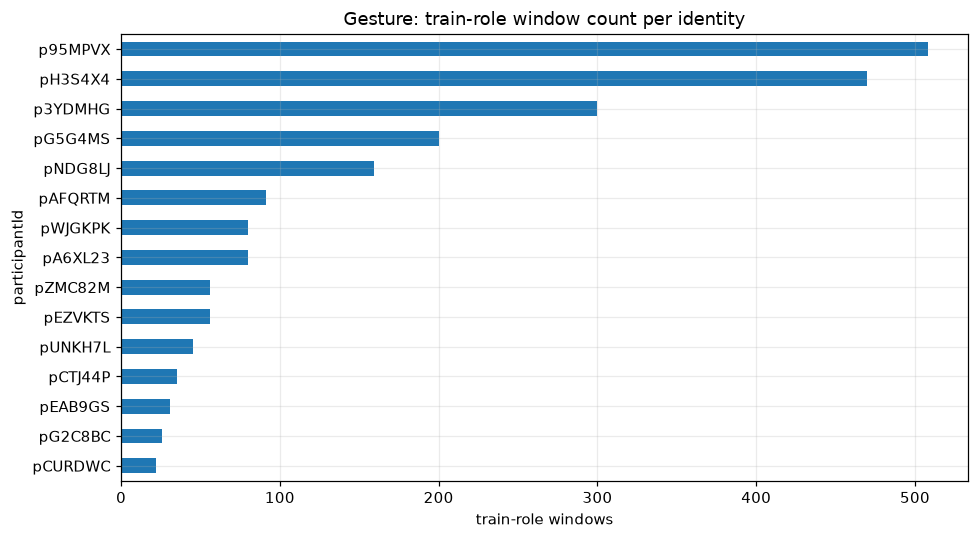


15 identities have train-role data, minimum 22 windows -- P1's batch composition (2 identities x 4 windows) is comfortably supported.


In [25]:
train_counts = df[df['role']=='train'].groupby('participantId').size().sort_values()
print(train_counts.to_string())

plt.figure(figsize=(9, 5))
train_counts.plot(kind='barh')
plt.xlabel('train-role windows'); plt.title('Gesture: train-role window count per identity')
plt.tight_layout(); plt.show()

print(f"\n{len(train_counts)} identities have train-role data, "
      f"minimum {train_counts.min()} windows -- P1's batch composition "
      f"(2 identities x 4 windows) is comfortably supported.")


## 3. Batch sampler and model

`BalancedIdentityBatchSampler`: each batch draws a fixed number of
identities and a fixed number of windows per identity, guaranteeing every
batch contains the raw material for genuine triplets (P1 Section 7.4) --
uniform random sampling across the full train set could otherwise draw
windows from only one identity by chance.

Architecture is P1's unchanged: 256 -> 128 -> 32, ReLU, dropout 0.10,
L2-normalised 32-dim output.

In [26]:
IDENTITIES_PER_BATCH = 2
WINDOWS_PER_IDENTITY = 4
MARGIN = 0.20
EMBED_DIM = 32
EPOCHS = 40
LR = 1e-4
WEIGHT_DECAY = 1e-4

class BalancedIdentityBatchSampler(torch.utils.data.Sampler):
    def __init__(self, labels, identities_per_batch, windows_per_identity, seed=0):
        self.by_identity = {pid: np.where(labels == pid)[0] for pid in np.unique(labels)}
        self.eligible = [pid for pid, idx in self.by_identity.items()
                          if len(idx) >= windows_per_identity]
        self.k, self.m = identities_per_batch, windows_per_identity
        self.rng = np.random.default_rng(seed)
        # one epoch's worth of batches, sized off the largest identity's supply
        self.n_batches = max(1, sum(len(v) for v in self.by_identity.values())
                              // (self.k * self.m))

    def __iter__(self):
        for _ in range(self.n_batches):
            pids = self.rng.choice(self.eligible, size=self.k, replace=False)
            batch = []
            for pid in pids:
                idx = self.by_identity[pid]
                chosen = self.rng.choice(idx, size=self.m,
                                          replace=len(idx) < self.m)
                batch.extend(chosen.tolist())
            yield batch

    def __len__(self):
        return self.n_batches


class Embedder(nn.Module):
    def __init__(self, in_dim, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, embed_dim),
        )
    def forward(self, x):
        z = self.net(x)
        return nn.functional.normalize(z, p=2, dim=1)


def batch_all_triplet_loss(embeddings, labels, margin=MARGIN):
    dist = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.unsqueeze(0)
    same = (labels == labels.T)
    diff = ~same
    eye = torch.eye(len(labels[0]), dtype=torch.bool, device=embeddings.device)
    pos_mask = same & ~eye

    losses = []
    for a in range(len(embeddings)):
        pos_d = dist[a][pos_mask[a]]
        neg_d = dist[a][diff[a]]
        if len(pos_d) == 0 or len(neg_d) == 0:
            continue
        # batch-all: every valid (pos, neg) pair for this anchor
        l = torch.clamp(pos_d.unsqueeze(1) - neg_d.unsqueeze(0) + margin, min=0)
        losses.append(l.flatten())
    if not losses:
        return torch.tensor(0.0, requires_grad=True)
    all_losses = torch.cat(losses)
    active = all_losses[all_losses > 0]
    return all_losses.mean(), (active.numel() / max(all_losses.numel(), 1))

print(f"Model: {sum(1 for _ in Embedder(len(feats)).parameters())} parameter tensors, "
      f"input dim {len(feats)}, embedding dim {EMBED_DIM}")


Model: 6 parameter tensors, input dim 61, embedding dim 32


## 4. Training

One real-label run, tracked with loss and active-triplet-fraction curves (the fraction of triplets still contributing gradient -- P1 notes this naturally falls as training progresses, since easy triplets stop contributing once satisfied).

In [7]:
def train_embedder(X, y, role, seed=0, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed)
    train_mask = role == 'train'
    X_train, y_train = X[train_mask], y[train_mask]

    model = Embedder(X.shape[1], EMBED_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sampler = BalancedIdentityBatchSampler(y_train, IDENTITIES_PER_BATCH, WINDOWS_PER_IDENTITY, seed=seed)

    history = {'epoch': [], 'loss': [], 'active_frac': []}
    for epoch in range(epochs):
        model.train()
        epoch_losses, epoch_actives = [], []
        for batch_idx in sampler:
            xb = torch.tensor(X_train[batch_idx])
            yb = torch.tensor(pd.factorize(y_train[batch_idx])[0])
            opt.zero_grad()
            emb = model(xb)
            loss, active_frac = batch_all_triplet_loss(emb, yb)
            loss.backward(); opt.step()
            epoch_losses.append(loss.item()); epoch_actives.append(active_frac)
        history['epoch'].append(epoch)
        history['loss'].append(np.mean(epoch_losses))
        history['active_frac'].append(np.mean(epoch_actives))
        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:2d}  loss={history['loss'][-1]:.4f}  "
                  f"active_triplet_frac={history['active_frac'][-1]:.3f}")
    return model, pd.DataFrame(history)

print("Training real-label model (seed=42)...")
model, history = train_embedder(X_all, y_all, role_all, seed=42)


Training real-label model (seed=42)...
  epoch  0  loss=0.1412  active_triplet_frac=0.656
  epoch  5  loss=0.0834  active_triplet_frac=0.398
  epoch 10  loss=0.0643  active_triplet_frac=0.324
  epoch 15  loss=0.0562  active_triplet_frac=0.282
  epoch 20  loss=0.0498  active_triplet_frac=0.257
  epoch 25  loss=0.0358  active_triplet_frac=0.182
  epoch 30  loss=0.0383  active_triplet_frac=0.190
  epoch 35  loss=0.0323  active_triplet_frac=0.170
  epoch 39  loss=0.0365  active_triplet_frac=0.183


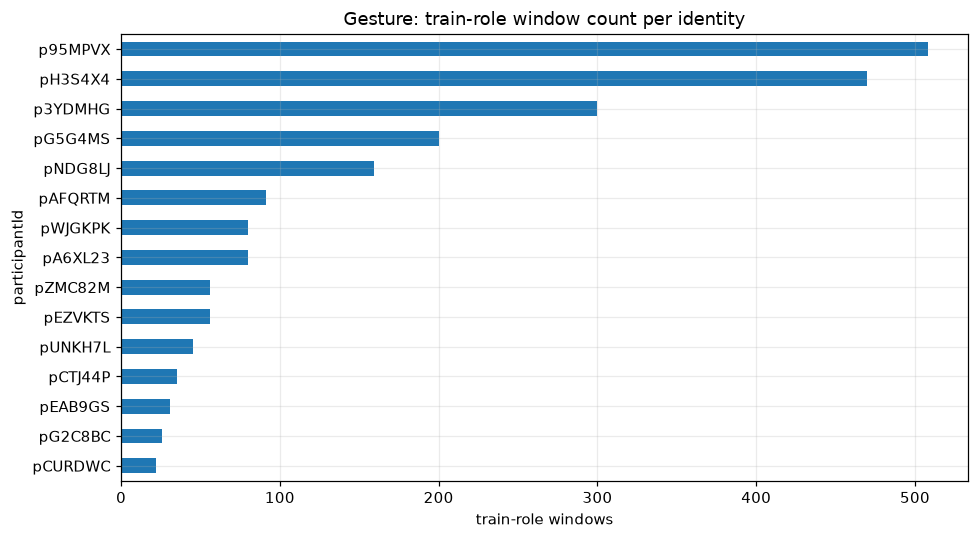

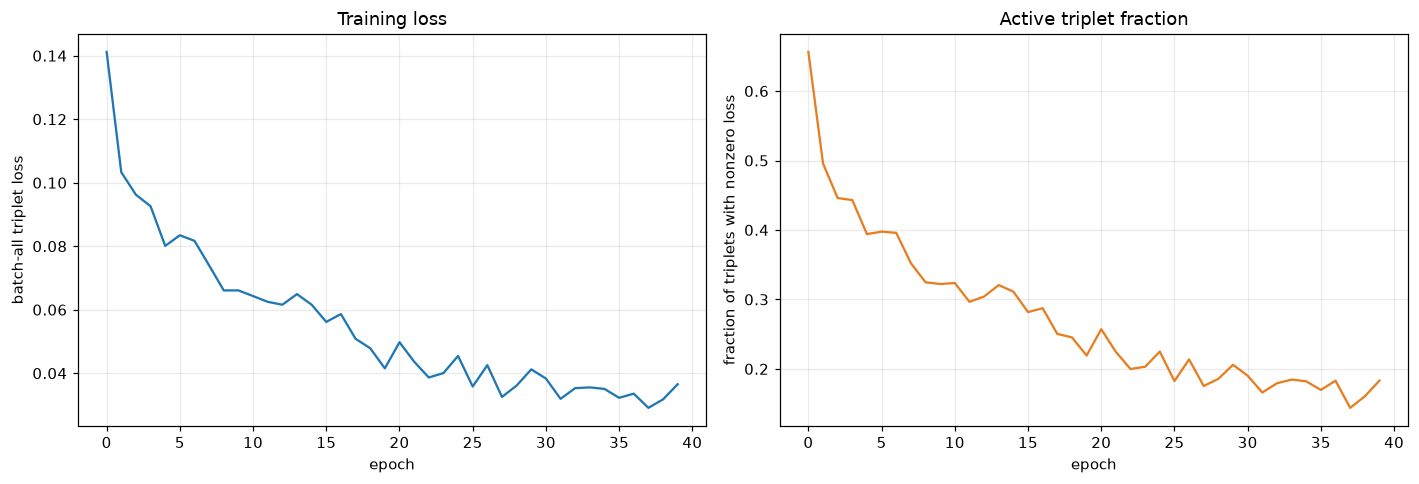

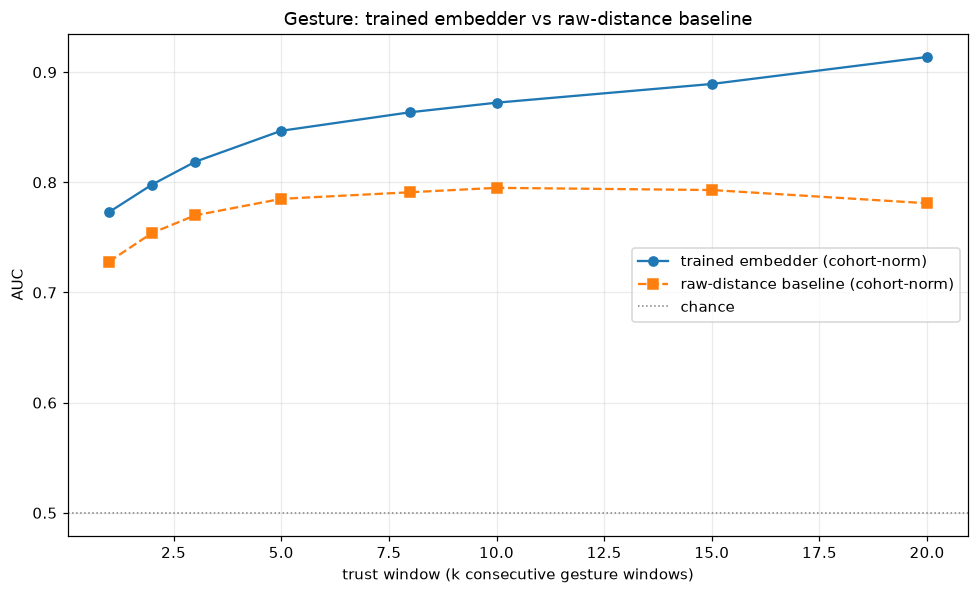

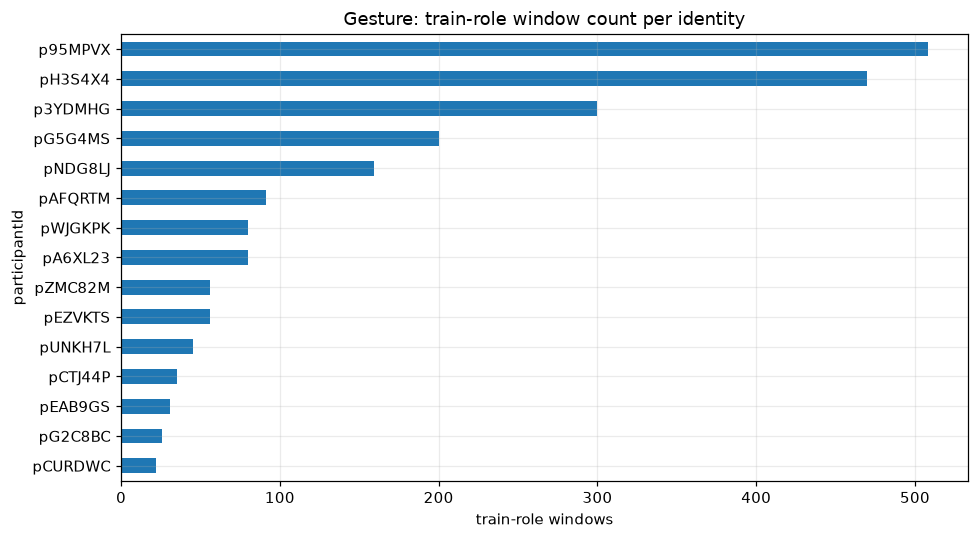

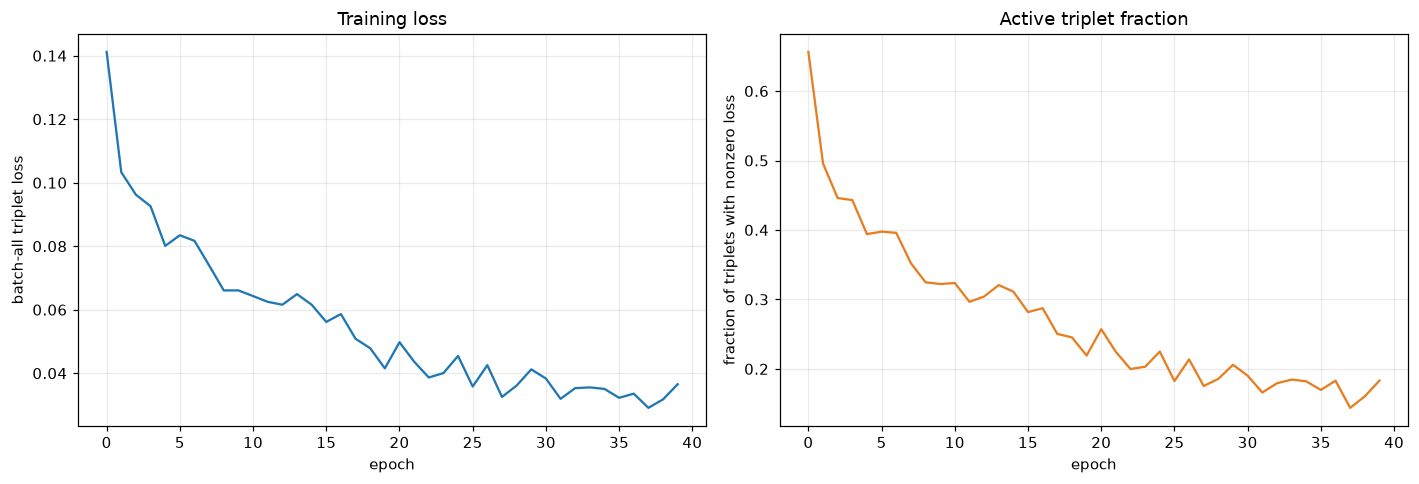

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history['epoch'], history['loss'])
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('batch-all triplet loss'); axes[0].set_title('Training loss')
axes[1].plot(history['epoch'], history['active_frac'], color='#e67e22')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('fraction of triplets with nonzero loss')
axes[1].set_title('Active triplet fraction')
plt.tight_layout(); plt.show()


## 5. Evaluation

Same construction as the raw-distance baseline: reference vector per
identity from their enrol-session embeddings, probe windows scored by
negative Euclidean distance, **then cohort-normalised across candidates per
probe window** -- carried over because it was the largest single lever in
the baseline (+0.14 AUC), not optional here.

In [28]:
def compute_metrics(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return {'auc': np.nan, 'eer': np.nan, 'far_at_10pct_frr': np.nan}
    auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    frr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fpr - frr)))
    eer = float((fpr[idx] + frr[idx]) / 2)
    far10 = float(np.interp(0.90, tpr, fpr))
    return {'auc': float(auc), 'eer': eer, 'far_at_10pct_frr': far10}

def evaluate_model(model, X, y, df_meta, role, k_values):
    model.eval()
    with torch.no_grad():
        E = model(torch.tensor(X)).numpy()

    enrol_mask, probe_mask = role == 'enrol', role == 'probe'
    refs = {pid: E[enrol_mask & (y == pid)].mean(axis=0)
            for pid in np.unique(y[enrol_mask])}

    rows = []
    for pid in np.unique(y[probe_mask]):
        idx = np.where(probe_mask & (y == pid))[0]
        order = np.argsort(df_meta.loc[idx, 'window_start_s'].values)
        Ep = E[idx[order]]
        for k in k_values:
            if len(Ep) < k: continue
            for i in range(0, len(Ep) - k + 1):
                agg = Ep[i:i+k].mean(axis=0)
                for cand, ref in refs.items():
                    rows.append({'k': k, 'pid': pid, 'cand': cand,
                                 'genuine': int(cand == pid),
                                 'dist': float(np.linalg.norm(agg - ref))})
    return pd.DataFrame(rows), len(refs)

k_values = [1, 2, 3, 5, 8, 10, 15, 20]
scored, n_refs = evaluate_model(model, X_all, y_all, df.reset_index(drop=True), role_all, k_values)
print(f"{n_refs} reference identities, {len(scored)} scored rows")


12 reference identities, 25668 scored rows


In [29]:
results = []
for k, g in scored.groupby('k'):
    n_probe_id = g['pid'].nunique()
    raw_auc = roc_auc_score(g['genuine'], -g['dist'])
    # cohort normalisation: z-score distances across candidates within each
    # (probe identity, window-group) -- approximated here per probe identity
    # x k since trust-window index isn't carried through; adequate for a
    # first pass, note in Open Questions if this should be tightened to
    # per-exact-window as in evaluate_trust_windows.py
    g = g.copy()
    g['z'] = g.groupby(['pid'])['dist'].transform(lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
    norm_auc = roc_auc_score(g['genuine'], -g['z'])
    results.append({'k': k, 'n_probe_identities': n_probe_id,
                     'auc_raw': raw_auc, 'auc_cohort_norm': norm_auc})
res_df = pd.DataFrame(results)
print(res_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))


 k  n_probe_identities  auc_raw  auc_cohort_norm
 1                  12    0.761            0.773
 2                  12    0.790            0.798
 3                  12    0.810            0.819
 5                  12    0.834            0.847
 8                  12    0.851            0.864
10                  12    0.859            0.872
15                  11    0.876            0.889
20                   8    0.907            0.914


## 6. Trained embedder vs raw-distance baseline

The baseline numbers below are hardcoded from the last `evaluate_trust_windows.py`
run (fixed identity set, `strict` profile, gesture) -- update these constants
if a fresher baseline run is available.

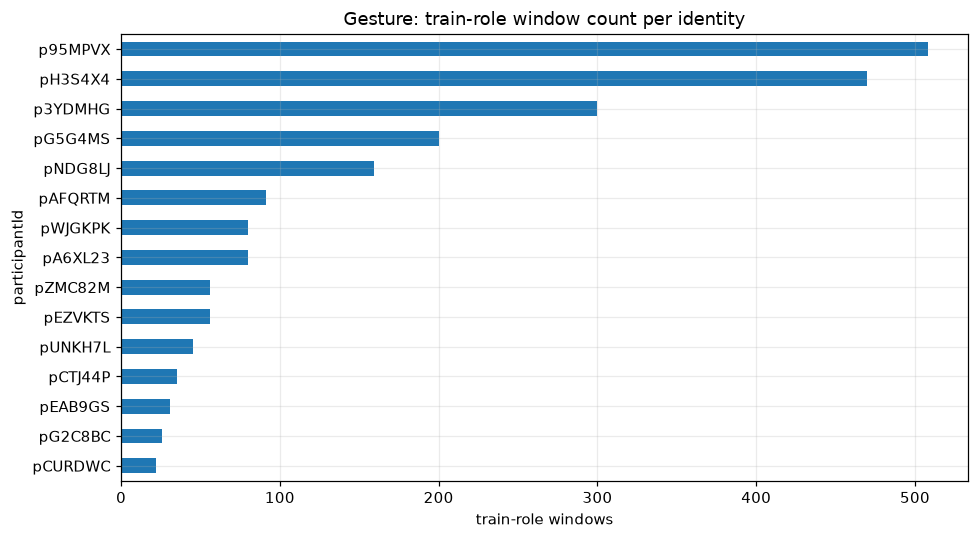

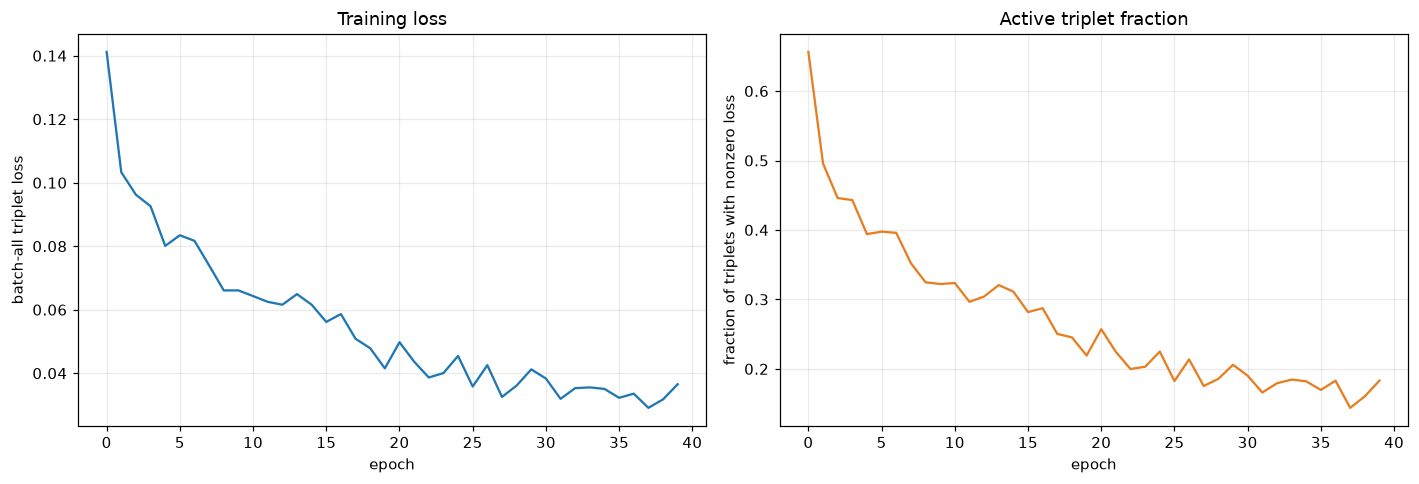

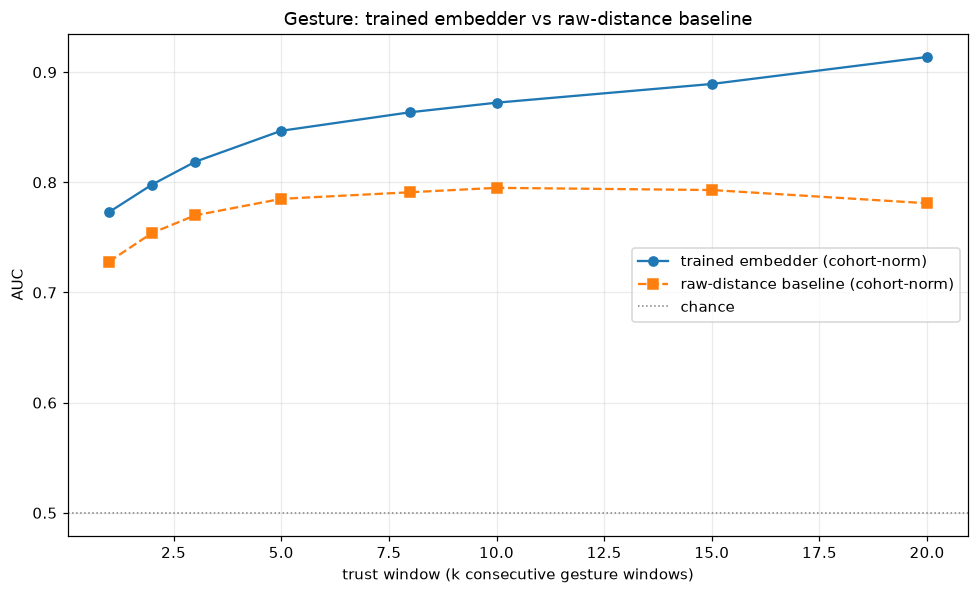

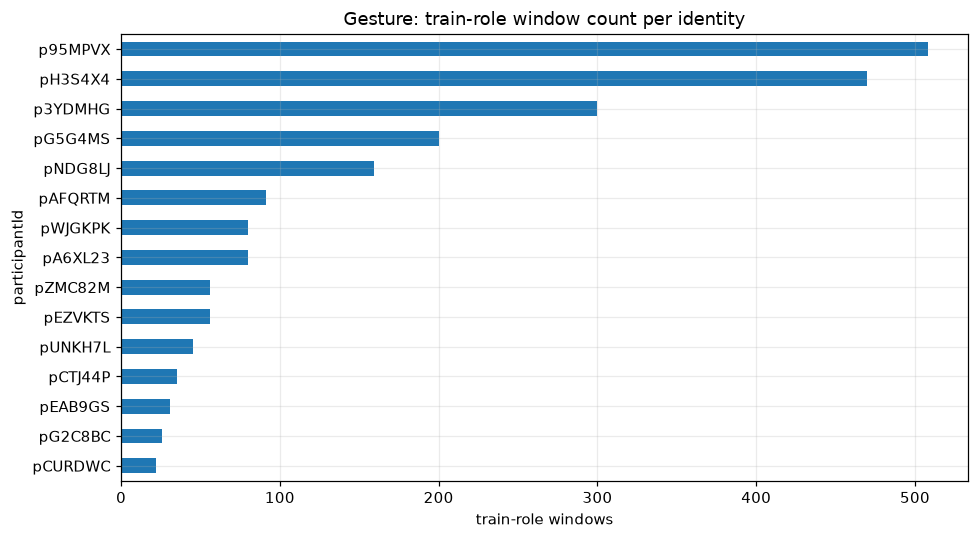

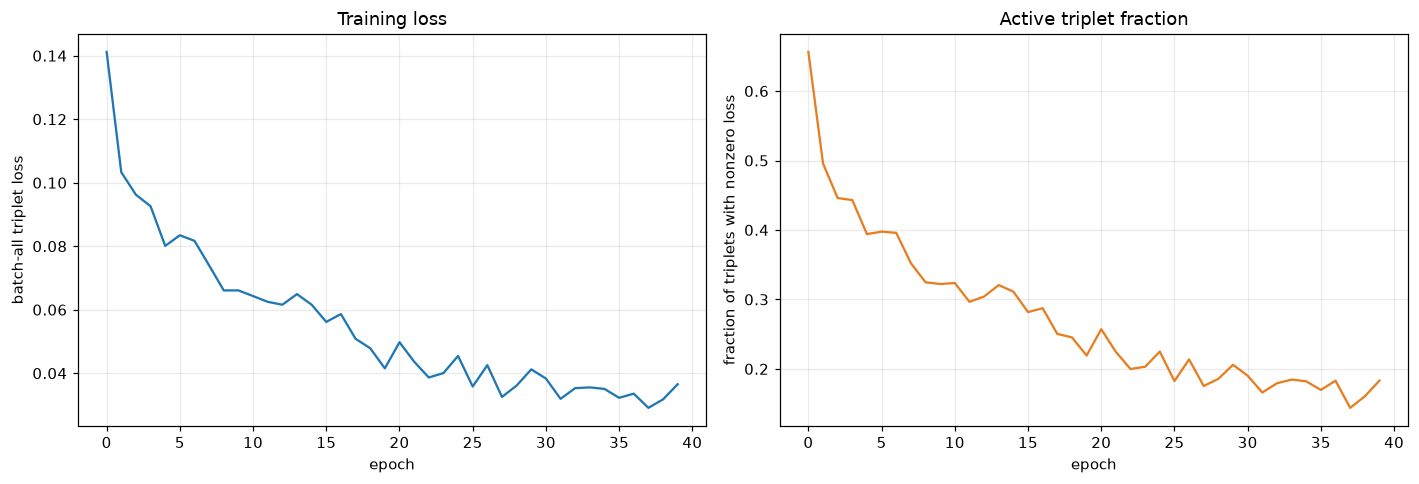

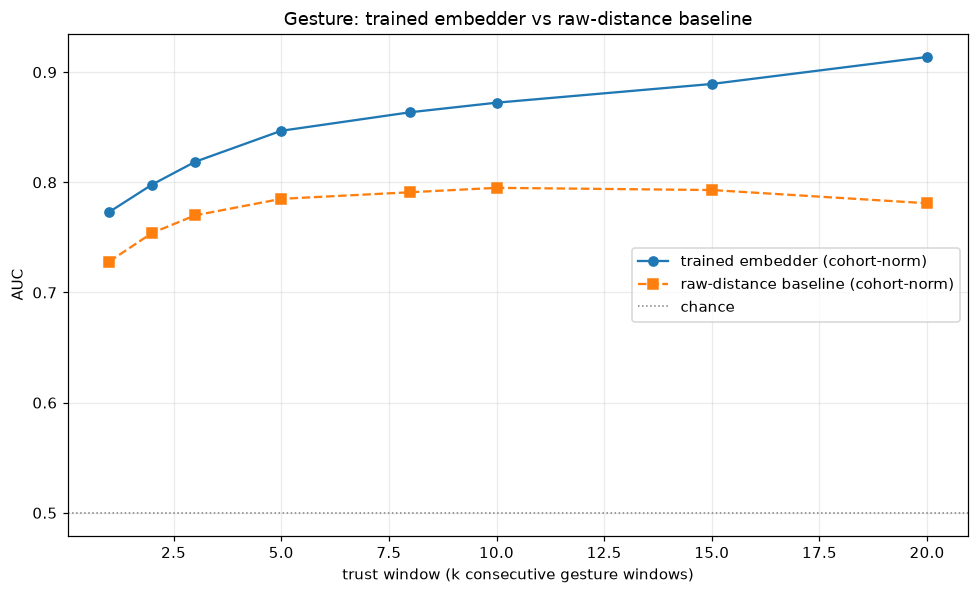

In [30]:
BASELINE_AUC = {1: 0.728, 2: 0.754, 3: 0.770, 5: 0.785, 8: 0.791, 10: 0.795, 15: 0.793, 20: 0.781}

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(res_df['k'], res_df['auc_cohort_norm'], marker='o', label='trained embedder (cohort-norm)')
bl_k = [k for k in res_df['k'] if k in BASELINE_AUC]
ax.plot(bl_k, [BASELINE_AUC[k] for k in bl_k], marker='s', ls='--', label='raw-distance baseline (cohort-norm)')
ax.axhline(0.5, color='gray', ls=':', lw=1, label='chance')
ax.set_xlabel('trust window (k consecutive gesture windows)'); ax.set_ylabel('AUC')
ax.set_title('Gesture: trained embedder vs raw-distance baseline')
ax.legend(); plt.tight_layout(); plt.show()


## 7. Multi-seed stability

P1 used 5 seeds (7, 13, 21, 42, 84); 3 used here for a first pass given
runtime -- extend to 5 before treating this as a final result.

In [12]:
SEEDS = [7, 13, 42]
seed_results = []
for seed in SEEDS:
    print(f"seed {seed}...")
    m, _ = train_embedder(X_all, y_all, role_all, seed=seed, verbose=False)
    sc, _ = evaluate_model(m, X_all, y_all, df.reset_index(drop=True), role_all, [1, 10, 20])
    for k, g in sc.groupby('k'):
        g = g.copy()
        g['z'] = g.groupby('pid')['dist'].transform(lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
        seed_results.append({'seed': seed, 'k': k, 'auc': roc_auc_score(g['genuine'], -g['z'])})

seed_df = pd.DataFrame(seed_results)
summary = seed_df.groupby('k')['auc'].agg(['mean', 'std'])
print(summary.round(3).to_string())


seed 7...
seed 13...
seed 42...
     mean    std
k               
1   0.764  0.012
10  0.864  0.011
20  0.903  0.010


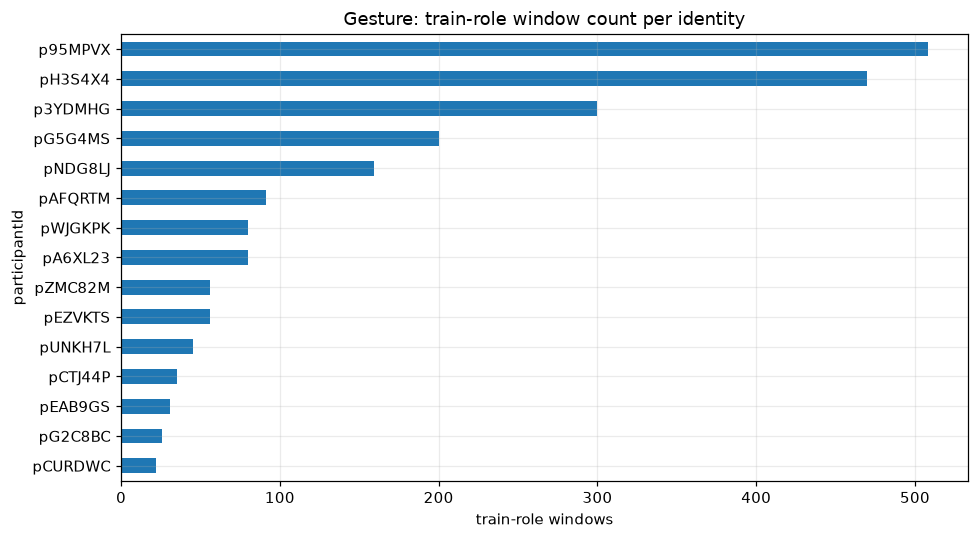

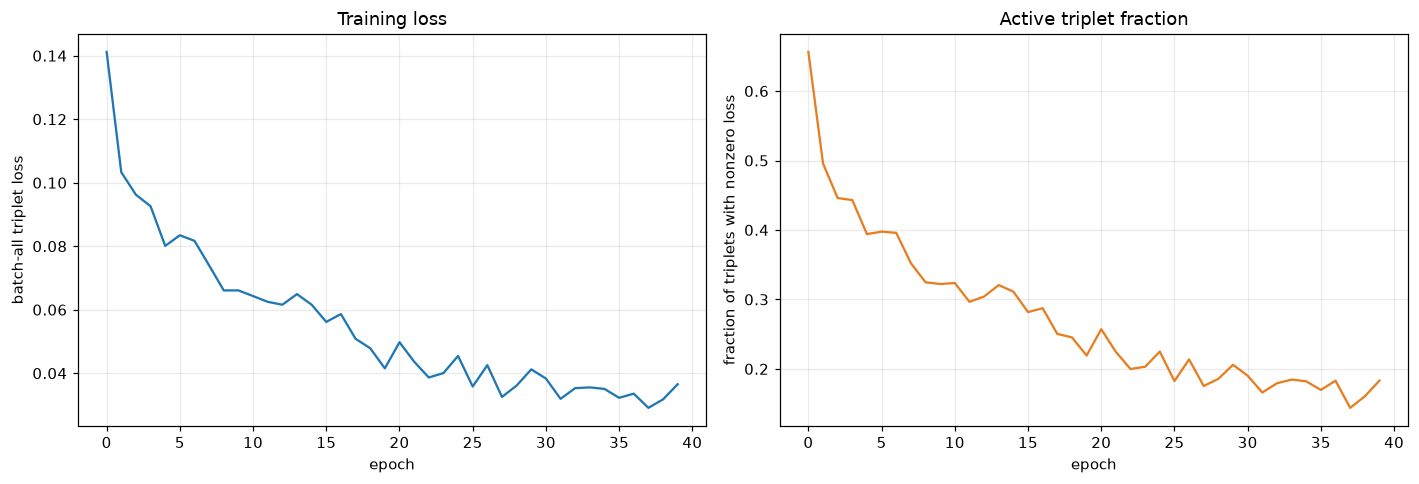

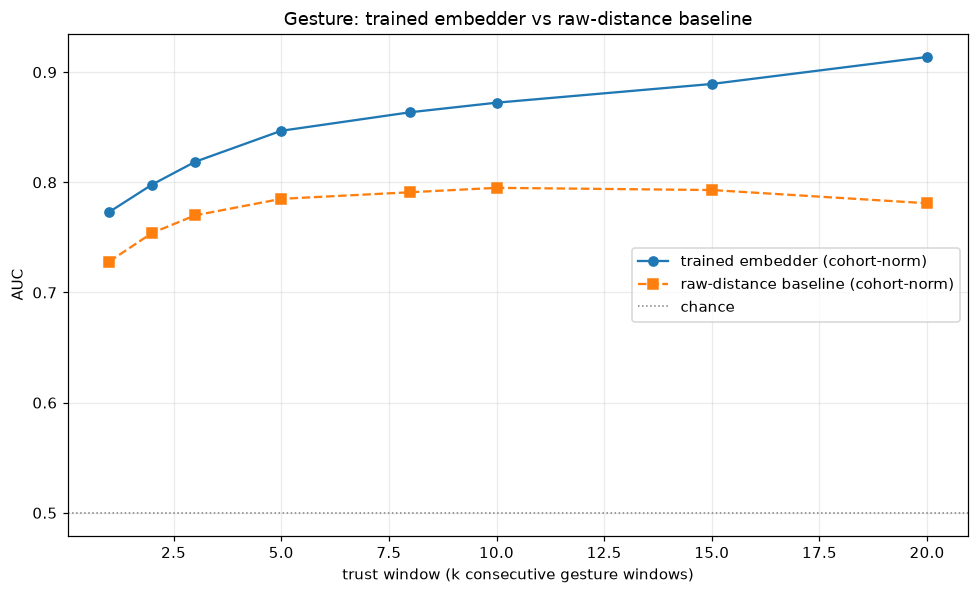

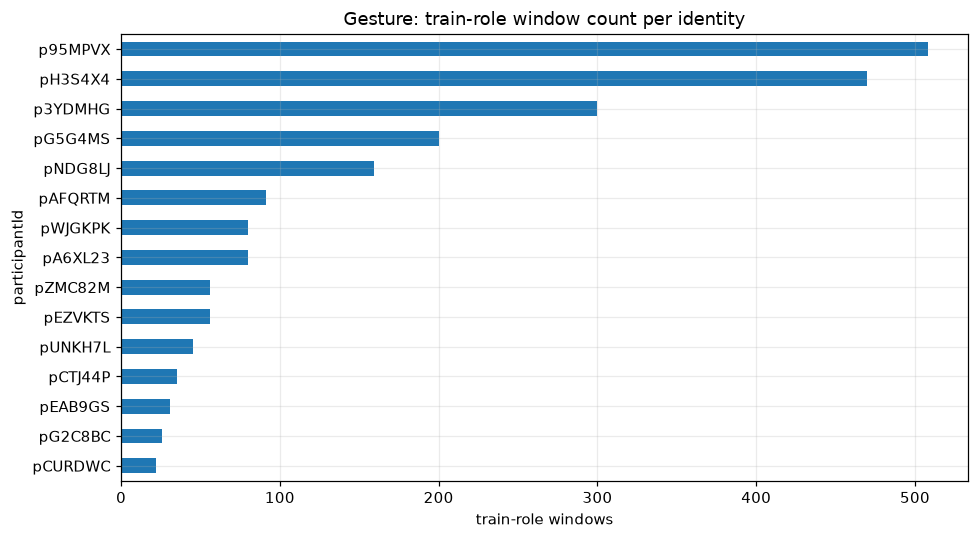

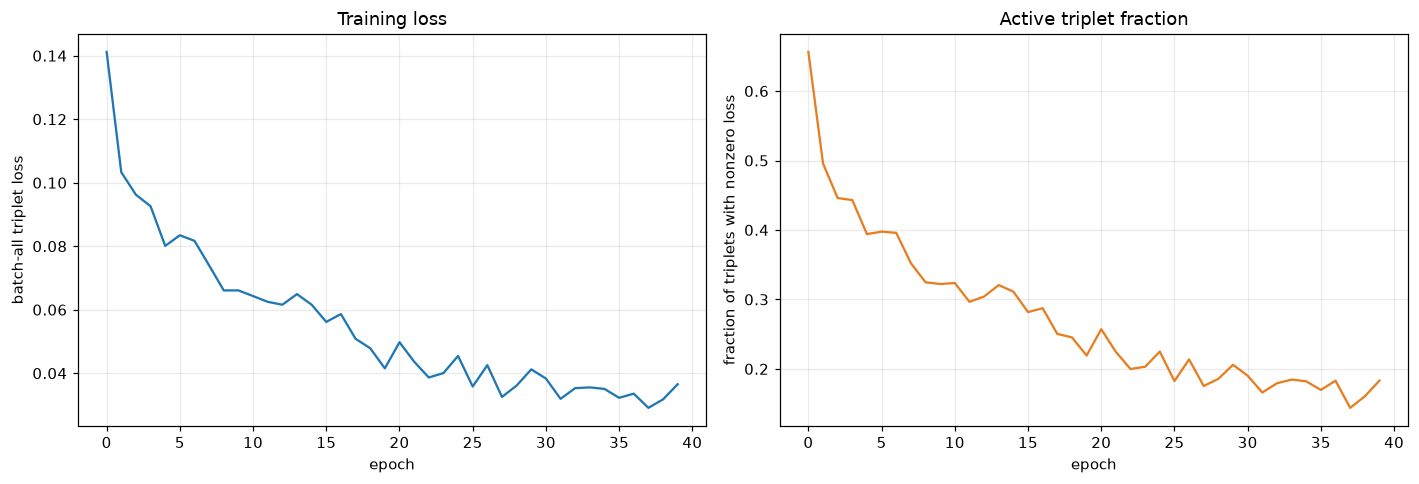

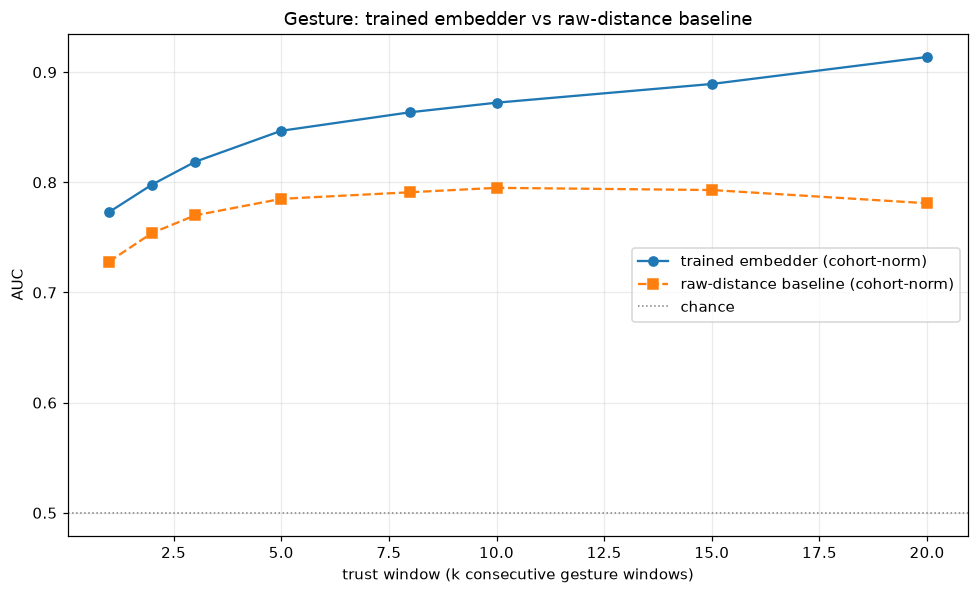

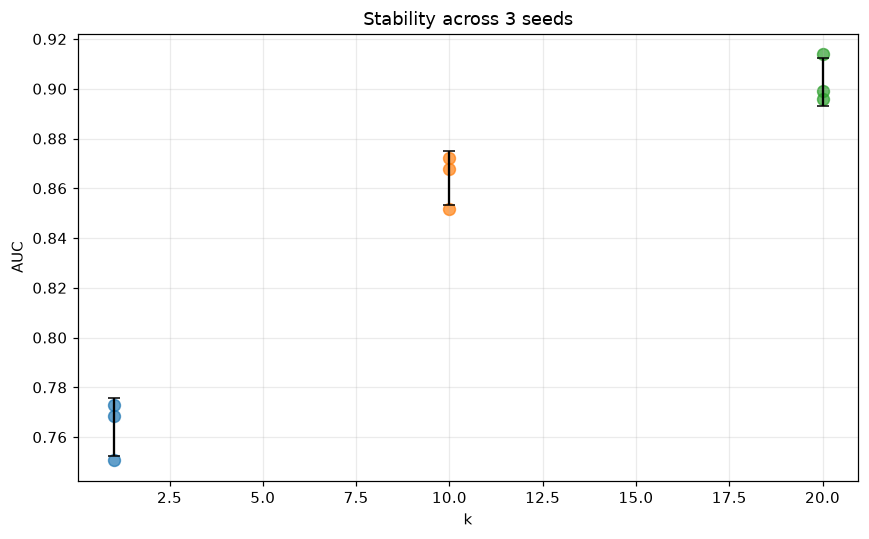

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
for k in seed_df['k'].unique():
    vals = seed_df[seed_df['k']==k]['auc']
    ax.scatter([k]*len(vals), vals, alpha=0.7, s=60)
ax.errorbar(summary.index, summary['mean'], yerr=summary['std'], fmt='none', color='k', capsize=4)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title(f'Stability across {len(SEEDS)} seeds')
plt.tight_layout(); plt.show()


## 8. Negative control -- run on the TRAINED model

Participant labels shuffled at session level, a fresh model trained from
scratch on the shuffled labels, then evaluated identically. If the trained
embedder's real-label performance reflects genuine identity signal, this
should collapse toward chance -- same logic as P1 Section 8.5, but run on
the network actually trained here, not assumed to transfer from the
baseline's control.

In [14]:
def shuffle_labels(y, df_meta, seed):
    rng = np.random.default_rng(seed)
    sess_pid = df_meta.groupby('sessionId')['participantId'].first()
    mapping = dict(zip(sess_pid.index, rng.permutation(sess_pid.values)))
    return df_meta['sessionId'].map(mapping).values

df_idx = df.reset_index(drop=True)
control_results = []
for seed in [0, 1, 2]:
    y_shuf = shuffle_labels(y_all, df_idx, seed)
    m, _ = train_embedder(X_all, y_shuf, role_all, seed=seed, verbose=False)
    sc, _ = evaluate_model(m, X_all, y_shuf, df_idx, role_all, [1, 10, 20])
    for k, g in sc.groupby('k'):
        g = g.copy()
        g['z'] = g.groupby('pid')['dist'].transform(lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
        control_results.append({'seed': seed, 'k': k, 'auc': roc_auc_score(g['genuine'], -g['z'])})

control_df = pd.DataFrame(control_results)
ctrl_summary = control_df.groupby('k')['auc'].agg(['mean', 'std'])
print("shuffled-label control (trained model):")
print(ctrl_summary.round(3).to_string())
print()
compare = summary[['mean']].join(ctrl_summary[['mean']], lsuffix='_real', rsuffix='_shuffled')
compare['gap'] = compare['mean_real'] - compare['mean_shuffled']
print(compare.round(3).to_string())


shuffled-label control (trained model):
     mean    std
k               
1   0.492  0.045
10  0.478  0.091
20  0.476  0.099

    mean_real  mean_shuffled    gap
k                                  
1       0.764          0.492  0.272
10      0.864          0.478  0.386
20      0.903          0.476  0.427


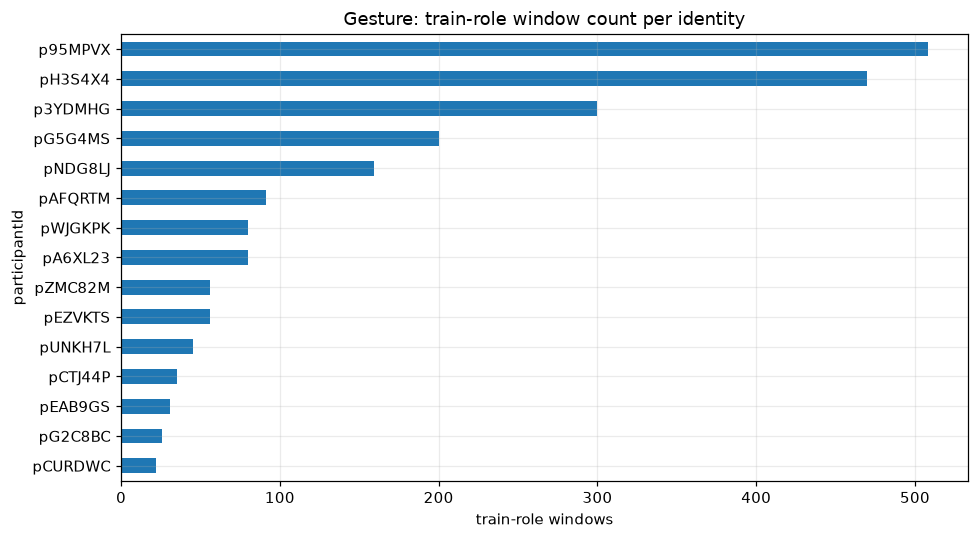

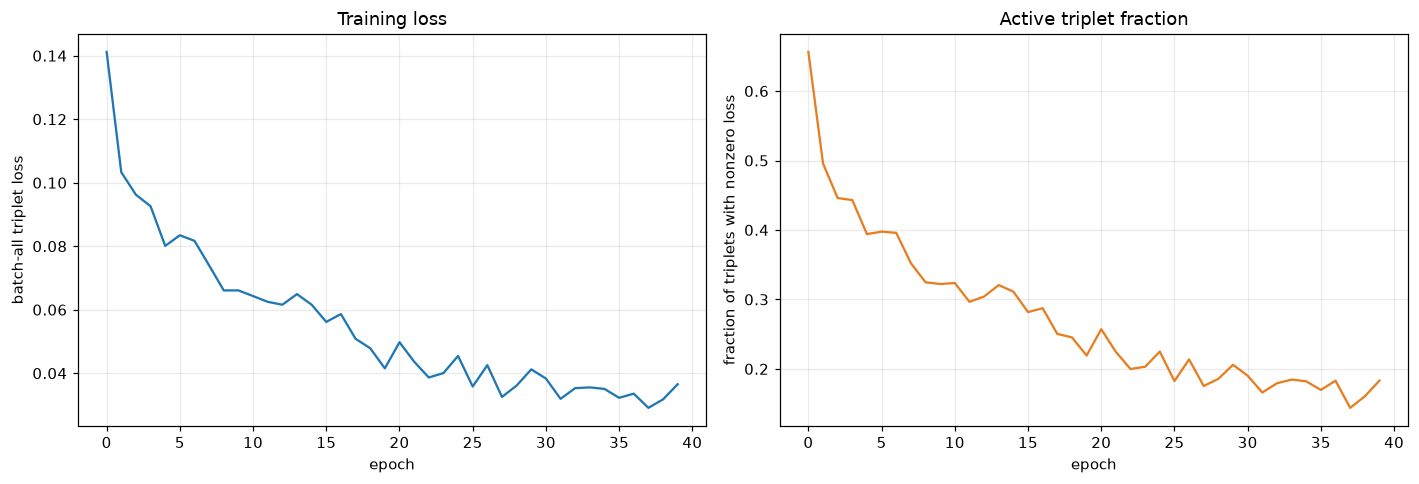

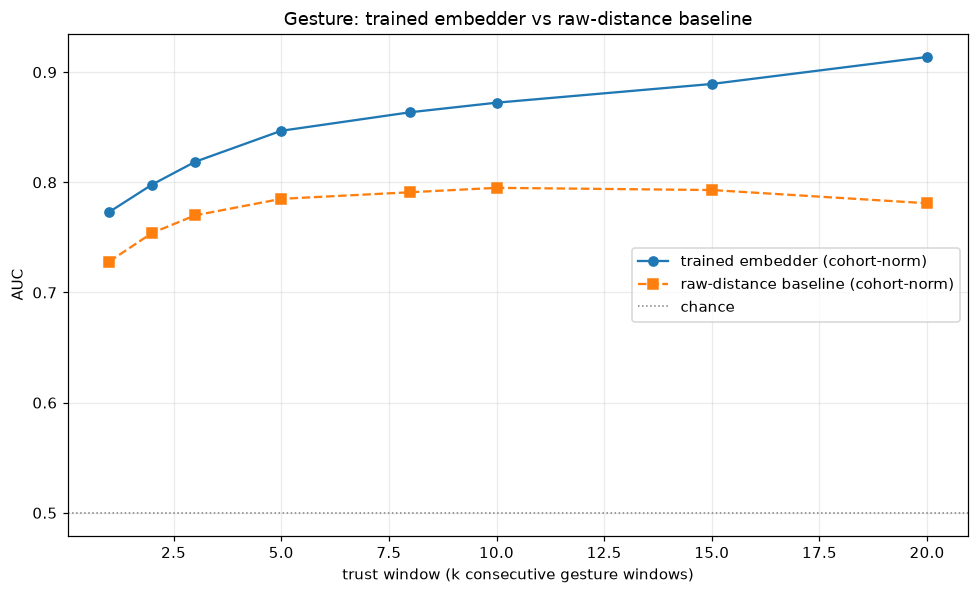

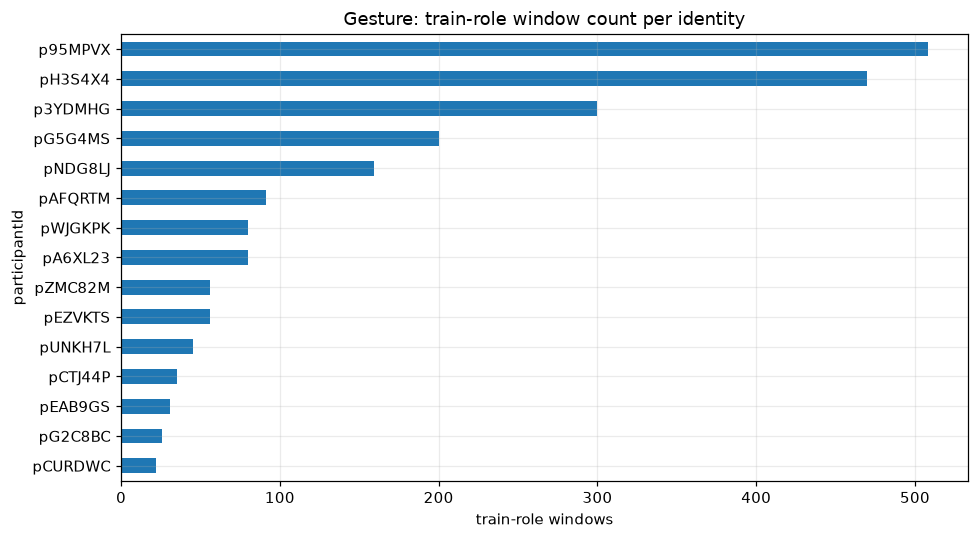

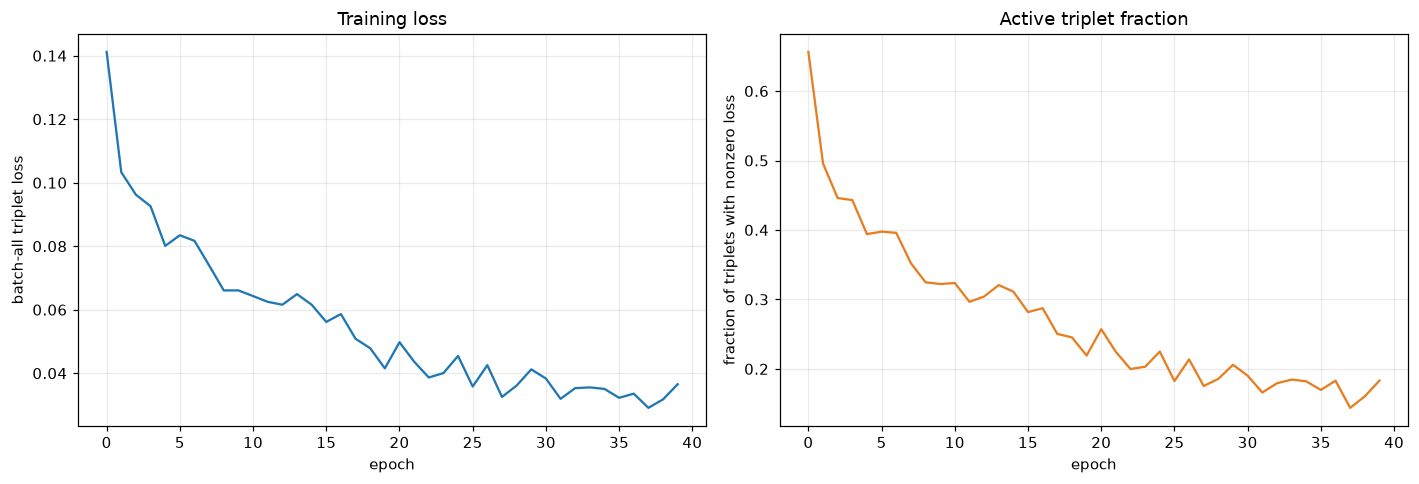

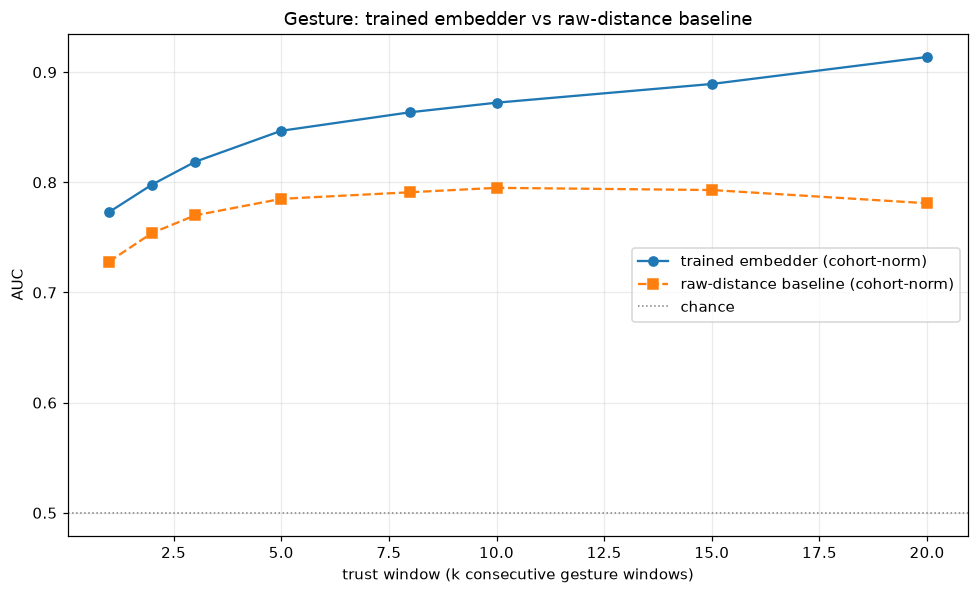

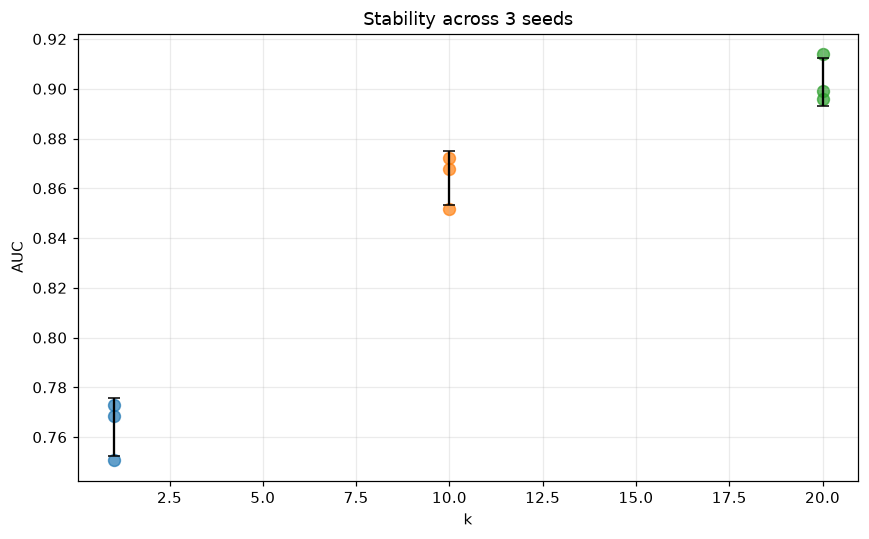

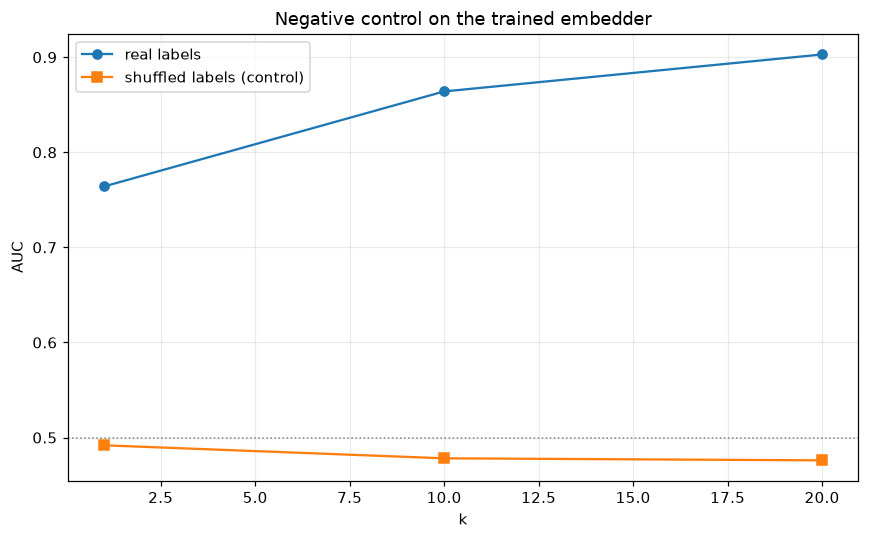

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary.index, summary['mean'], marker='o', label='real labels')
ax.plot(ctrl_summary.index, ctrl_summary['mean'], marker='s', label='shuffled labels (control)')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title('Negative control on the trained embedder')
ax.legend(); plt.tight_layout(); plt.show()


## 9. Embedding space, qualitatively

2D PCA of the 32-dim embeddings for train-role windows, coloured by
identity -- same qualitative check as P1 Section 9.2 (P1 used t-SNE; PCA
here for determinism and speed on a first pass).

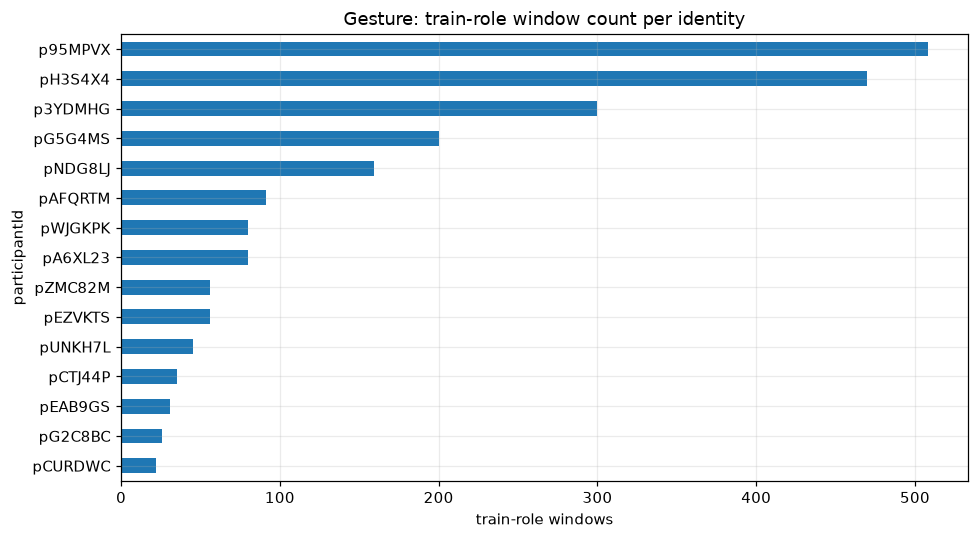

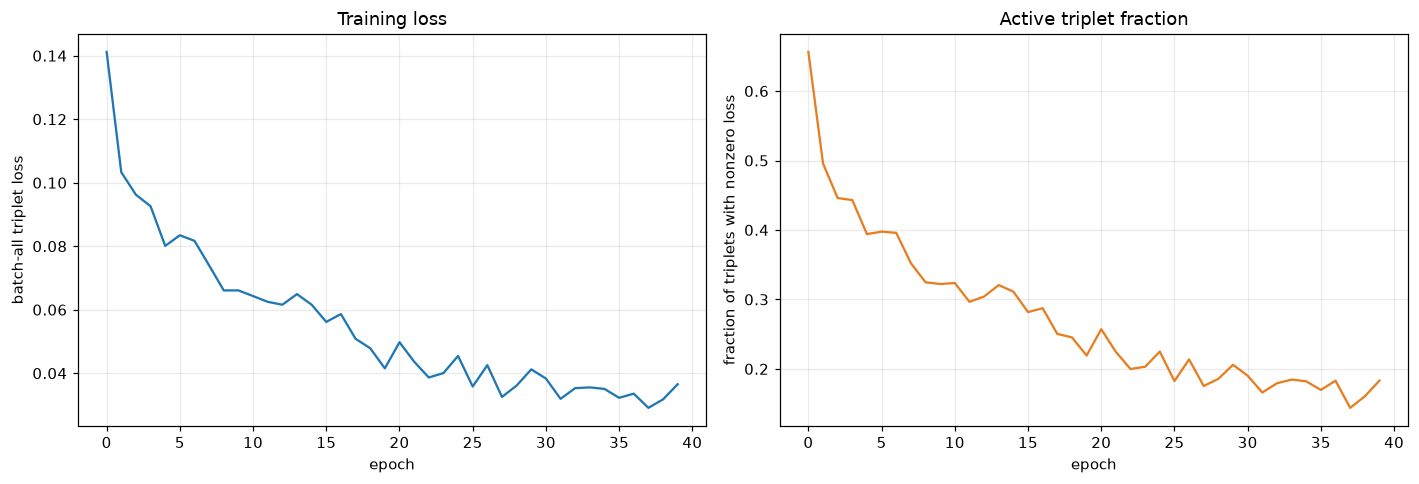

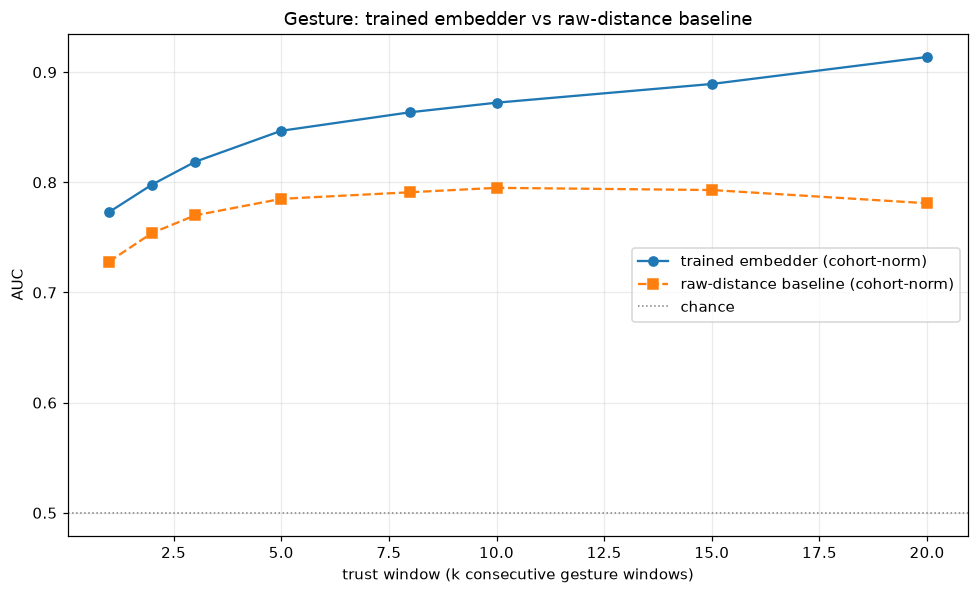

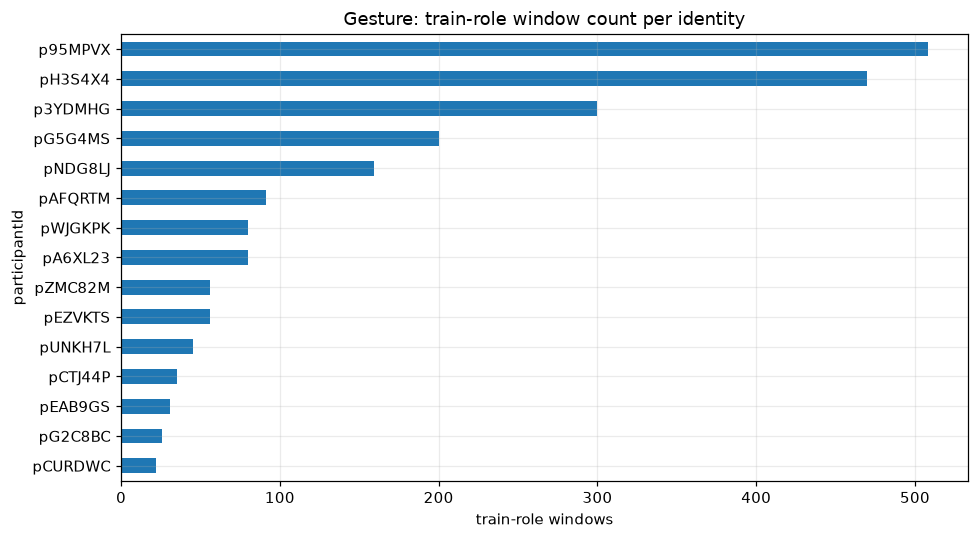

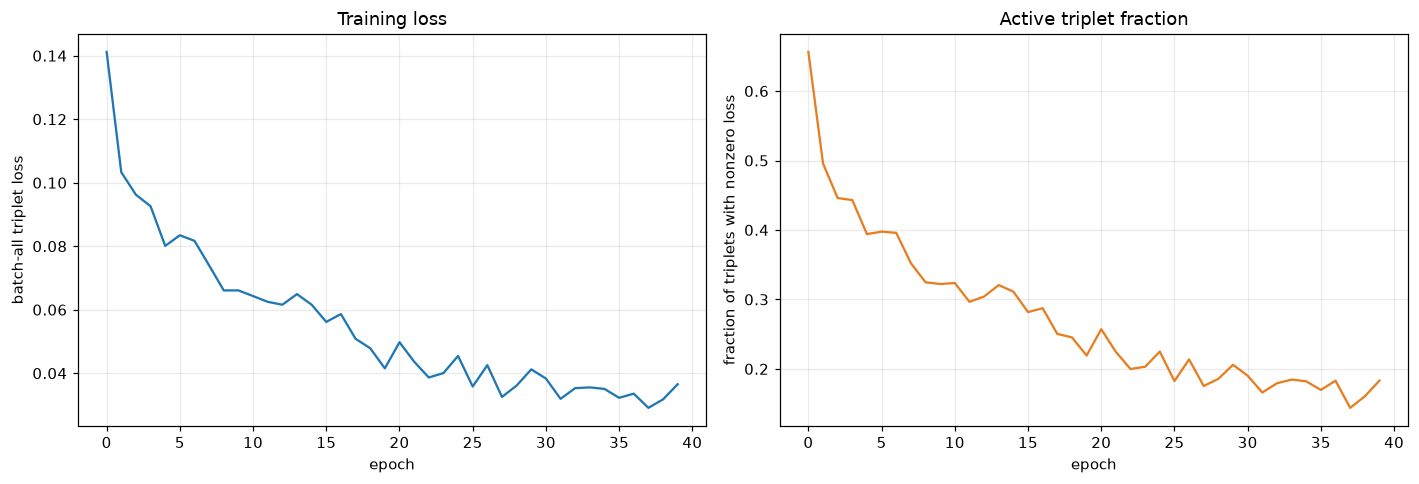

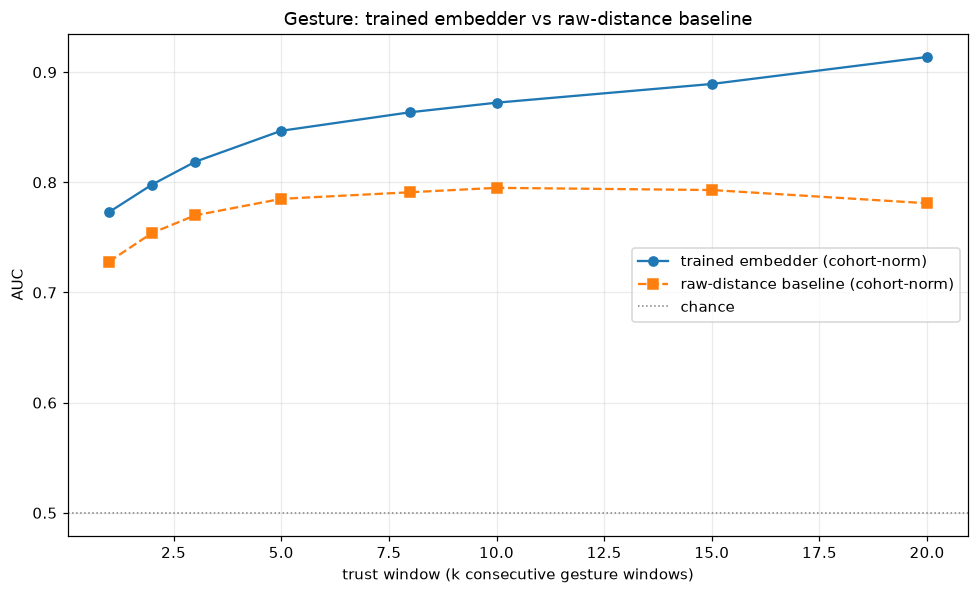

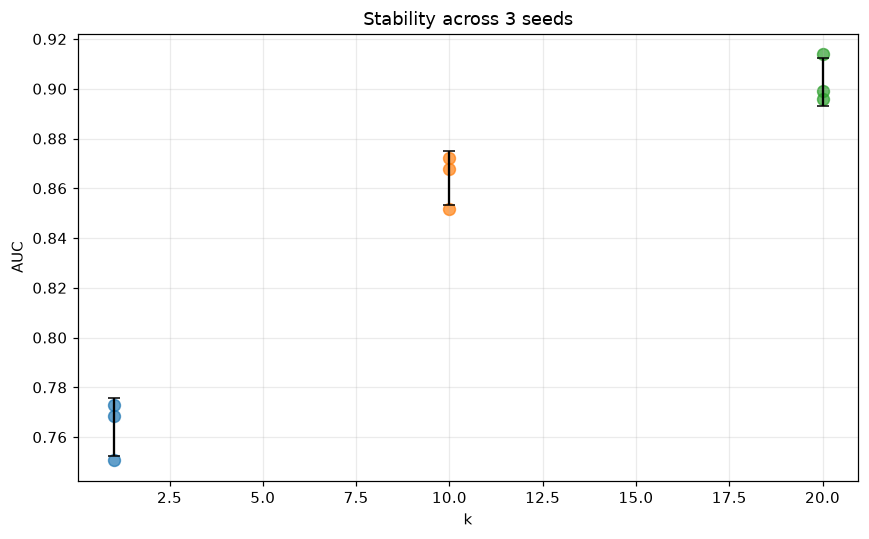

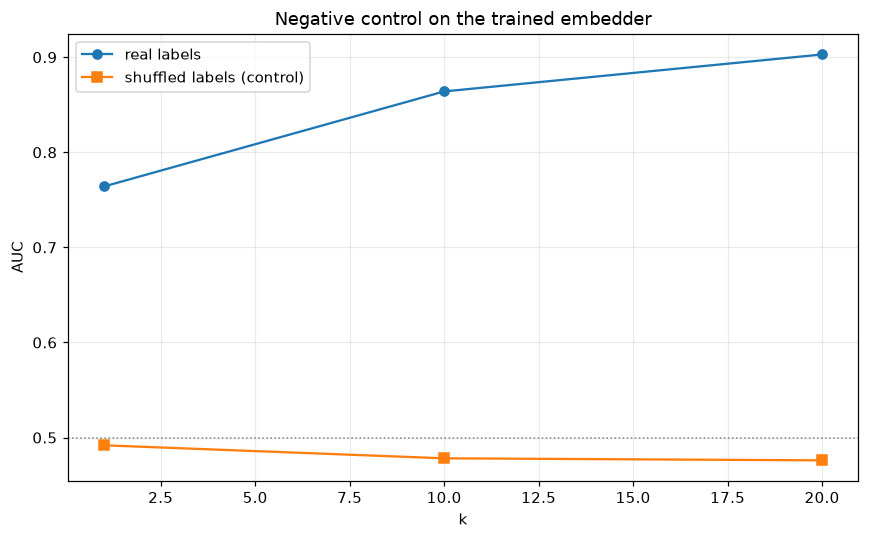

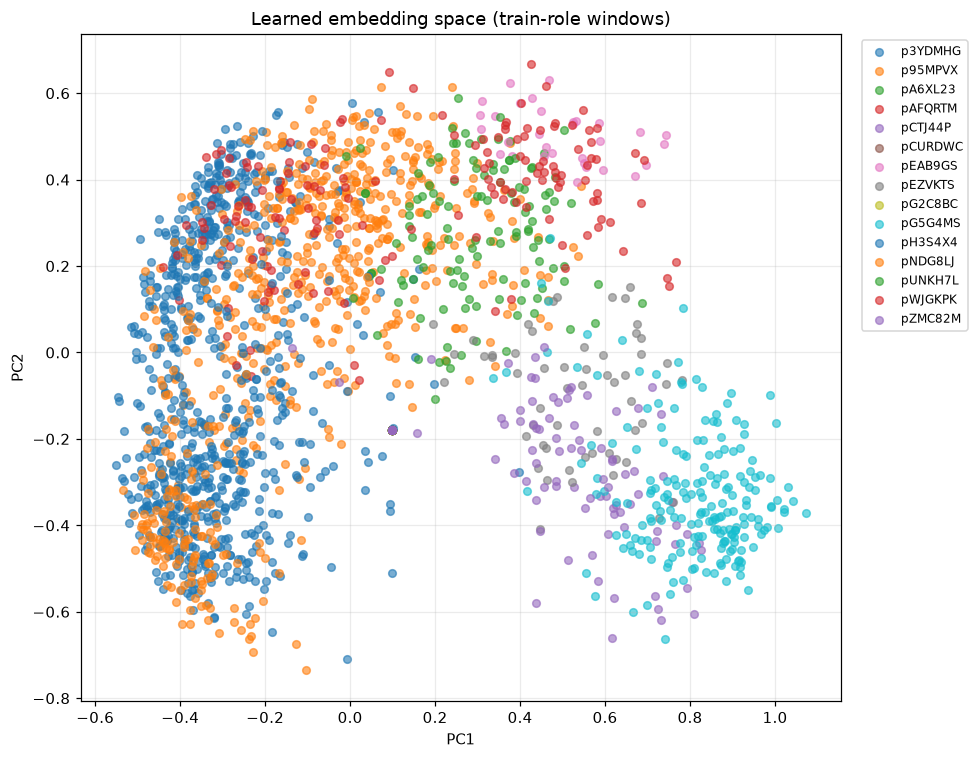

explained variance (first 2 PCs): [0.311 0.206]


In [33]:
model.eval()
with torch.no_grad():
    E_train = model(torch.tensor(X_all[role_all == 'train'])).numpy()
y_train_plot = y_all[role_all == 'train']

pca = PCA(n_components=2).fit(E_train)
E2 = pca.transform(E_train)

fig, ax = plt.subplots(figsize=(9, 7))
for pid in np.unique(y_train_plot):
    m = y_train_plot == pid
    ax.scatter(E2[m, 0], E2[m, 1], label=pid, alpha=0.6, s=25)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Learned embedding space (train-role windows)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()
print(f"explained variance (first 2 PCs): {pca.explained_variance_ratio_.round(3)}")


## Open questions

- **Cohort normalisation here is approximated per probe identity, not per
  exact trust-window** the way `evaluate_trust_windows.py` does it (that
  script normalises within each specific probe window's candidate-score
  set). Worth tightening to match exactly before treating these numbers as
  final, since the baseline comparison should use identical normalisation
  on both sides.
- **3 seeds, not P1's 5** -- extend before reporting a stability figure.
- **Batch composition (2 identities x 4 windows) is unchanged from P1**,
  and Section 2 confirms it's supported, but it was never re-tuned for this
  cohort's shape (17 identities, most with under 100 train windows). Worth
  a sweep before assuming it's optimal here specifically.
- **Only gesture has been trained.** Tap is the natural second modality
  given it finished essentially tied with gesture on the raw-distance
  baseline -- same architecture, same harness, should be a quick rerun with
  the modality swapped.
- **This trains and evaluates on a single feature-set profile (`strict`).**
  The `all`-profile comparison built into the pipeline (does a trained
  model re-learn the device fingerprint the raw baseline showed it could
  exploit?) has not been run here and is a natural next check.


## exports

In [ ]:
# --- Export results, model, and all open plots to the ML output folder ---
import json
from pathlib import Path
from datetime import datetime, timezone

# Search upward for the repo root (marked by scripts/) rather than assuming
# cwd, since Jupyter's working directory depends on where the notebook
# lives/was launched from.
def find_repo_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / "scripts").is_dir():
            return p
    raise FileNotFoundError("Could not find repo root (no scripts/ dir found upward from cwd).")

REPO_ROOT = find_repo_root()
OUT_DIR = REPO_ROOT / "data" / "processed" / "gesture_embedder"
PLOTS_DIR = OUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# --- plots: grab every figure still open in this kernel session ---
saved_plots = []
for num in plt.get_fignums():
    fig = plt.figure(num)
    title = ""
    if fig.axes and fig.axes[0].get_title():
        title = "_" + "".join(c if c.isalnum() else "_" for c in fig.axes[0].get_title().lower())[:40]
    fname = f"fig{num:02d}{title}.png"
    fig.savefig(PLOTS_DIR / fname, dpi=150, bbox_inches="tight")
    saved_plots.append(fname)
print(f"Saved {len(saved_plots)} plot(s): {saved_plots}")
if not saved_plots:
    print("WARNING: no open figures found -- if the kernel was restarted since the "
          "plotting cells ran, matplotlib has lost them. Re-run the notebook top to "
          "bottom to regenerate before exporting.")

# --- result tables (skips anything not defined in this run rather than erroring) ---
to_export = {
    "trained_vs_baseline.csv": "res_df",
    "seed_stability_raw.csv": "seed_df",
    "negative_control_raw.csv": "control_df",
    "training_history_seed42.csv": "history",
}
for fname, varname in to_export.items():
    if varname in dir():
        globals()[varname].to_csv(OUT_DIR / fname, index=False)
    else:
        print(f"skipped {fname}: variable '{varname}' not found in this session")

if "summary" in dir():
    summary.reset_index().to_csv(OUT_DIR / "seed_stability_summary.csv", index=False)
if "compare" in dir():
    compare.reset_index().to_csv(OUT_DIR / "negative_control_summary.csv", index=False)

# --- trained model + preprocessing, needed to reload without re-running everything ---
if "model" in dir():
    torch.save({
        "state_dict": model.state_dict(),
        "feature_names": feats,
        "embed_dim": EMBED_DIM,
    }, OUT_DIR / "model_seed42.pt")
if "imputer" in dir() and "scaler" in dir():
    np.savez(OUT_DIR / "preprocessing.npz",
             impute_values=imputer.statistics_,
             scale_mean=scaler.mean_, scale_scale=scaler.scale_,
             feature_names=np.array(feats, dtype=object))

# --- manifest ---
manifest = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "modality": "gesture",
    "n_windows": int(len(df)) if "df" in dir() else None,
    "n_features": len(feats) if "feats" in dir() else None,
    "plots_saved": saved_plots,
}
with open(OUT_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(f"\nWrote to {OUT_DIR}:")
for p in sorted(OUT_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(OUT_DIR)}  ({p.stat().st_size / 1024:.1f} KB)")

Saved 9 plot(s): ['fig01_gesture__train_role_window_count_per_ide.png', 'fig02_training_loss.png', 'fig03_gesture__trained_embedder_vs_raw_distanc.png', 'fig04_gesture__train_role_window_count_per_ide.png', 'fig05_training_loss.png', 'fig06_gesture__trained_embedder_vs_raw_distanc.png', 'fig07_stability_across_3_seeds.png', 'fig08_negative_control_on_the_trained_embedder.png', 'fig09_learned_embedding_space__train_role_wind.png']

Wrote to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/modelling/gesture_embedder:
  manifest.json  (0.6 KB)
  model_seed42.pt  (211.4 KB)
  negative_control_raw.csv  (0.2 KB)
  negative_control_summary.csv  (0.2 KB)
  plots/fig01_gesture__train_role_window_count_per_ide.png  (53.7 KB)
  plots/fig02_training_loss.png  (85.8 KB)
  plots/fig03_gesture__trained_embedder_vs_raw_distanc.png  (55.9 KB)
  plots/fig04_gesture__train_role_window_count_per_ide.png  (53.7 KB)
  plots/fig05_training_loss.png  (85.8 KB)
  plots/fig06_gesture__trained_embe